## Core Question:

Are our Amazon advertising campaigns profitable and efficient?

## Sub-Questions:

Which campaigns/products have the highest ACOS?

Which campaigns generate the best ROAS?

Are we overspending on low-performing campaigns?

Is ad spend actually driving profitable sales?

Which campaigns should we scale vs cut?

### Setup packages and import data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(
    "Data_Analysis_Business/Project11_Client_Case_Study/week_data.csv",
    encoding="latin1"
)

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2589 entries, 0 to 2588
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ï»¿week             2589 non-null   object 
 1   search_query        2589 non-null   object 
 2   search_query_score  2589 non-null   int64  
 3   search_quey_volume  2589 non-null   int64  
 4   imp_total_count     2589 non-null   int64  
 5   imp_ASIN_count      2589 non-null   int64  
 6   imp_ASIN_share      2589 non-null   float64
 7   clk_total_count     2589 non-null   int64  
 8   clk_click_rate      2589 non-null   float64
 9   clk_ASIN_count      2589 non-null   int64  
 10  clk_ASIN_share      2589 non-null   float64
 11  cart_total_count    2589 non-null   int64  
 12  cart_add_rate       2589 non-null   float64
 13  cart_ASIN_count     2589 non-null   int64  
 14  cart_ASIN_share     2589 non-null   float64
 15  pur_total_count     2589 non-null   int64  
 16  pur_pu

### Data cleaning

In [3]:
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2575 entries, 0 to 2588
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ï»¿week             2575 non-null   object 
 1   search_query        2575 non-null   object 
 2   search_query_score  2575 non-null   int64  
 3   search_quey_volume  2575 non-null   int64  
 4   imp_total_count     2575 non-null   int64  
 5   imp_ASIN_count      2575 non-null   int64  
 6   imp_ASIN_share      2575 non-null   float64
 7   clk_total_count     2575 non-null   int64  
 8   clk_click_rate      2575 non-null   float64
 9   clk_ASIN_count      2575 non-null   int64  
 10  clk_ASIN_share      2575 non-null   float64
 11  cart_total_count    2575 non-null   int64  
 12  cart_add_rate       2575 non-null   float64
 13  cart_ASIN_count     2575 non-null   int64  
 14  cart_ASIN_share     2575 non-null   float64
 15  pur_total_count     2575 non-null   int64  
 16  pur_purchas

### Creating variable ad spend (becuase I dont have the data)

First renaming a column in the dataset as there's a slight typo

In [5]:
df.rename(columns={'search_quey_volume': 'search_query_volume'}, inplace=True)

In [6]:
import numpy as np

np.random.seed(42)

# Base CPC (cost per click)
df['cpc'] = np.random.uniform(0.3, 2.0, len(df))

# Adjust CPC based on search volume (more volume = more competition)
df['cpc'] = df['cpc'] * (1 + df['search_query_volume'] / df['search_query_volume'].max())

# Calculate ad spend
df['ad_spend'] = df['cpc'] * df['clk_total_count']

Check that it worked

In [7]:
df[['cpc', 'ad_spend']].describe()

,cpc,ad_spend
count,2575.000000,2.575000e+03
mean,1.150451,2.015081e+03
std,0.496058,2.515490e+04
min,0.302662,3.054711e-01
25%,0.713024,9.180429e+00
50%,1.162301,6.701178e+01
75%,1.581422,3.984303e+02
max,2.054945,1.152628e+06


### Create variable pricing (becuase I dont have the data)

In [8]:
import numpy as np

np.random.seed(42)

# Create price tiers
df['price'] = np.random.choice(
    [12, 18, 25, 35, 50, 75],
    size=len(df),
    p=[0.2, 0.25, 0.25, 0.15, 0.1, 0.05]
)

In [9]:
df['price'] = df['price'] * np.random.uniform(0.9, 1.1, len(df))

### Create Revenue, ACOS & ROAS

In [10]:
df['revenue'] = df['pur_total_count'] * df['price']

In [11]:
df['acos'] = df['ad_spend'] / df['revenue']
df['roas'] = df['revenue'] / df['ad_spend']

### Group and created summary metrics

In [13]:
summary = df.groupby('search_query').agg({
    'imp_total_count': 'sum',
    'clk_total_count': 'sum',
    'pur_total_count': 'sum',
    'ad_spend': 'sum',
    'revenue': 'sum'
}).reset_index()

In [14]:
summary['acos'] = summary['ad_spend'] / summary['revenue']
summary['roas'] = summary['revenue'] / summary['ad_spend']
summary['conversion_rate'] = summary['pur_total_count'] / summary['clk_total_count']

### Classify the campaign

In [16]:
winners = summary[(summary['roas'] > 4) & (summary['conversion_rate'] > 0.1)]

In [17]:
losers = summary[(summary['roas'] < 2) & (summary['conversion_rate'] < 0.05)]

In [18]:
high_spend_low_return = summary[(summary['ad_spend'] > summary['ad_spend'].quantile(0.75)) & (summary['roas'] < 2)]

### Check visuals

Spend vs Revenue

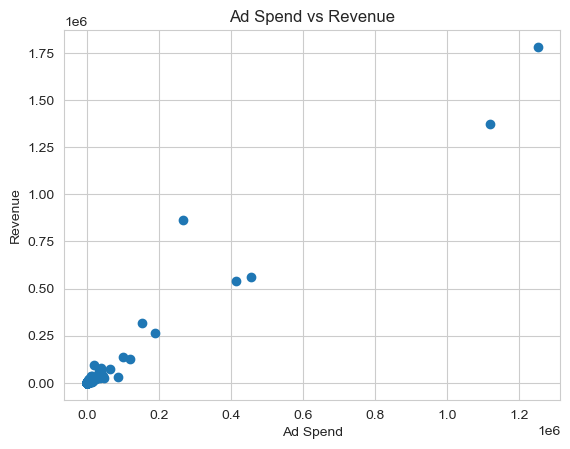

In [19]:
import matplotlib.pyplot as plt

plt.scatter(summary['ad_spend'], summary['revenue'])
plt.xlabel('Ad Spend')
plt.ylabel('Revenue')
plt.title('Ad Spend vs Revenue')
plt.show()

ROAS Distribution

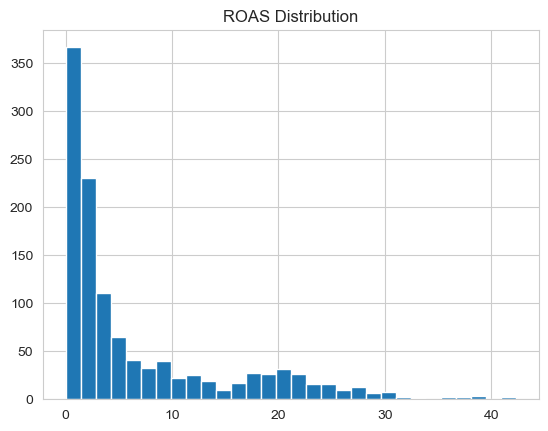

In [20]:
summary['roas'].hist(bins=30)
plt.title('ROAS Distribution')
plt.show()

### Run Top 10's to help with recommendations

In [21]:
# Top 10 search queries by revenue
top_10_revenue = summary.sort_values('revenue', ascending=False).head(10)
top_10_revenue

,search_query,imp_total_count,clk_total_count,pur_total_count,ad_spend,revenue,acos,roas,conversion_rate
937,stocking stuffers for adults,107046669,791740,110779,1.251400e+06,1.781264e+06,0.702535,1.423417,0.139918
359,fidget toys,72722061,917863,57052,1.119025e+06,1.371014e+06,0.816202,1.225187,0.062157
142,baby toys,12502857,129882,16735,2.669004e+05,8.656801e+05,0.308313,3.243458,0.128848
774,sensory toys,40462148,478463,26636,4.548417e+05,5.602097e+05,0.811913,1.231659,0.055670
794,sensory toys for autistic children,22949132,327549,18942,4.124585e+05,5.413347e+05,0.761929,1.312459,0.057830
938,stocking stuffers for men,21981952,206564,26240,1.517692e+05,3.166230e+05,0.479337,2.086214,0.127031
69,autism sensory toys,10939543,142224,7803,1.880477e+05,2.666806e+05,0.705142,1.418154,0.054864
810,sensory toys for kids 5-7,6516064,85025,5271,1.010666e+05,1.385672e+05,0.729369,1.371049,0.061994
331,fidget,12054854,124219,5201,1.205018e+05,1.275322e+05,0.944874,1.058343,0.041870
869,slinky,586664,10852,1774,1.880919e+04,9.301538e+04,0.202216,4.945209,0.163472


In [22]:
# Top 10 search queries by ROAS
top_10_roas = summary.sort_values('roas', ascending=False).head(10)
top_10_roas

,search_query,imp_total_count,clk_total_count,pur_total_count,ad_spend,revenue,acos,roas,conversion_rate
228,bunmo stretch,19,1,1,1.938830,82.131156,0.023607,42.361191,1.0
389,fidget toys for kids textured,20,1,1,1.918081,78.902414,0.024310,41.136130,1.0
239,bunmo textured,38,2,2,3.883797,152.452099,0.025476,39.253369,1.0
93,autism toys calming,38,1,1,1.940703,76.079938,0.025509,39.202258,1.0
503,kids fidget rope,60,1,1,1.987789,77.850703,0.025533,39.164466,1.0
729,sensory seeker fidget,180,1,1,0.343880,13.090958,0.026269,38.068353,1.0
945,stress relief for autistic kids,271,1,1,1.957153,72.378168,0.027041,36.981352,1.0
110,autistic restrainer,120,1,1,1.938155,70.831138,0.027363,36.545649,1.0
1164,worm chewies,48,1,1,0.368186,13.176798,0.027942,35.788452,1.0
1021,tapping fidgets,60,1,1,0.339699,11.086514,0.030641,32.636320,1.0


In [23]:
# Top 10 ROAS queries with a minimum ad spend threshold
top_10_roas_filtered = summary[summary['ad_spend'] > summary['ad_spend'].quantile(0.25)] \
    .sort_values('roas', ascending=False) \
    .head(10)

top_10_roas_filtered

,search_query,imp_total_count,clk_total_count,pur_total_count,ad_spend,revenue,acos,roas,conversion_rate
239,bunmo textured,38,2,2,3.883797,152.452099,0.025476,39.253369,1.000000
980,stretchy stim toys,38,2,2,3.603898,114.837681,0.031383,31.864857,1.000000
146,beads for individuals with disabilities,299,2,2,3.603781,105.374943,0.034200,29.240105,1.000000
192,bunmo 6pk textured noodle sensory toys/ calmin...,48,2,2,3.792831,107.413381,0.035311,28.320105,1.000000
597,quiet nap time toys,240,7,5,13.956390,380.478165,0.036681,27.261932,0.714286
184,bunmo 6pk textured noodle,254,6,5,7.094012,172.931368,0.041022,24.377091,0.833333
288,chewy noodles sensory,191,5,3,9.582369,232.142294,0.041278,24.225981,0.600000
731,sensory seeking car toys,90,3,3,4.596317,102.365513,0.044901,22.271202,1.000000
204,bunmo sensory,422,6,3,3.826402,85.009658,0.045011,22.216602,0.500000
829,sensory toys for visually impaired,114,6,3,11.547666,245.767155,0.046986,21.282842,0.500000


In [24]:
# Bottom 10 search queries by ROAS
bottom_10_roas = summary.sort_values('roas', ascending=True).head(10)
bottom_10_roas

,search_query,imp_total_count,clk_total_count,pur_total_count,ad_spend,revenue,acos,roas,conversion_rate
585,proprioceptive sensory toys,2396,36,0,45.483229,0.0,inf,0.0,0.0
327,enabling devices toys for special children,1644,28,0,28.413114,0.0,inf,0.0,0.0
1018,tactile sensory wall panels,304,10,0,8.153221,0.0,inf,0.0,0.0
378,fidget toys bunmo,120,2,0,1.957675,0.0,inf,0.0,0.0
382,fidget toys for autism and anxiety,1164,22,0,16.384683,0.0,inf,0.0,0.0
386,fidget toys for disabled adults,228,4,0,5.635127,0.0,inf,0.0,0.0
397,fidget toys stretchy,1193,17,0,22.814105,0.0,inf,0.0,0.0
403,fidgeting finger springs,1675,19,0,18.387168,0.0,inf,0.0,0.0
409,fidgets for autism prek,95,4,0,6.650454,0.0,inf,0.0,0.0
973,stretchy figits,57,5,0,9.467804,0.0,inf,0.0,0.0


In [25]:
# Cleaner display
cols_to_show = ['search_query', 'ad_spend', 'revenue', 'roas', 'acos', 'conversion_rate']

top_10_revenue[cols_to_show]
top_10_roas[cols_to_show]
top_10_roas_filtered[cols_to_show]
bottom_10_roas[cols_to_show]

,search_query,ad_spend,revenue,roas,acos,conversion_rate
585,proprioceptive sensory toys,45.483229,0.0,0.0,inf,0.0
327,enabling devices toys for special children,28.413114,0.0,0.0,inf,0.0
1018,tactile sensory wall panels,8.153221,0.0,0.0,inf,0.0
378,fidget toys bunmo,1.957675,0.0,0.0,inf,0.0
382,fidget toys for autism and anxiety,16.384683,0.0,0.0,inf,0.0
386,fidget toys for disabled adults,5.635127,0.0,0.0,inf,0.0
397,fidget toys stretchy,22.814105,0.0,0.0,inf,0.0
403,fidgeting finger springs,18.387168,0.0,0.0,inf,0.0
409,fidgets for autism prek,6.650454,0.0,0.0,inf,0.0
973,stretchy figits,9.467804,0.0,0.0,inf,0.0


In [26]:
# Top 10 search queries by clicks
top_10_clicks = summary.sort_values('clk_total_count', ascending=False).head(10)
top_10_clicks

,search_query,imp_total_count,clk_total_count,pur_total_count,ad_spend,revenue,acos,roas,conversion_rate
359,fidget toys,72722061,917863,57052,1.119025e+06,1.371014e+06,0.816202,1.225187,0.062157
937,stocking stuffers for adults,107046669,791740,110779,1.251400e+06,1.781264e+06,0.702535,1.423417,0.139918
774,sensory toys,40462148,478463,26636,4.548417e+05,5.602097e+05,0.811913,1.231659,0.055670
794,sensory toys for autistic children,22949132,327549,18942,4.124585e+05,5.413347e+05,0.761929,1.312459,0.057830
938,stocking stuffers for men,21981952,206564,26240,1.517692e+05,3.166230e+05,0.479337,2.086214,0.127031
69,autism sensory toys,10939543,142224,7803,1.880477e+05,2.666806e+05,0.705142,1.418154,0.054864
142,baby toys,12502857,129882,16735,2.669004e+05,8.656801e+05,0.308313,3.243458,0.128848
331,fidget,12054854,124219,5201,1.205018e+05,1.275322e+05,0.944874,1.058343,0.041870
810,sensory toys for kids 5-7,6516064,85025,5271,1.010666e+05,1.385672e+05,0.729369,1.371049,0.061994
91,autism toys,5559603,64436,3007,6.516068e+04,7.181199e+04,0.907379,1.102076,0.046666


In [27]:
# Top 10 search queries by purchases
top_10_purchases = summary.sort_values('pur_total_count', ascending=False).head(10)
top_10_purchases

,search_query,imp_total_count,clk_total_count,pur_total_count,ad_spend,revenue,acos,roas,conversion_rate
937,stocking stuffers for adults,107046669,791740,110779,1.251400e+06,1.781264e+06,0.702535,1.423417,0.139918
359,fidget toys,72722061,917863,57052,1.119025e+06,1.371014e+06,0.816202,1.225187,0.062157
774,sensory toys,40462148,478463,26636,4.548417e+05,5.602097e+05,0.811913,1.231659,0.055670
938,stocking stuffers for men,21981952,206564,26240,1.517692e+05,3.166230e+05,0.479337,2.086214,0.127031
794,sensory toys for autistic children,22949132,327549,18942,4.124585e+05,5.413347e+05,0.761929,1.312459,0.057830
142,baby toys,12502857,129882,16735,2.669004e+05,8.656801e+05,0.308313,3.243458,0.128848
69,autism sensory toys,10939543,142224,7803,1.880477e+05,2.666806e+05,0.705142,1.418154,0.054864
810,sensory toys for kids 5-7,6516064,85025,5271,1.010666e+05,1.385672e+05,0.729369,1.371049,0.061994
331,fidget,12054854,124219,5201,1.205018e+05,1.275322e+05,0.944874,1.058343,0.041870
388,fidget toys for kids 8-12,2422697,35951,3567,3.345043e+04,6.185007e+04,0.540831,1.849007,0.099218


In [29]:
# Top 10 winners by ROAS
top_winners_roas = winners.sort_values('roas', ascending=False).head(10)
top_winners_roas[cols_to_show]

,search_query,ad_spend,revenue,roas,acos,conversion_rate
228,bunmo stretch,1.938830,82.131156,42.361191,0.023607,1.0
389,fidget toys for kids textured,1.918081,78.902414,41.136130,0.024310,1.0
239,bunmo textured,3.883797,152.452099,39.253369,0.025476,1.0
93,autism toys calming,1.940703,76.079938,39.202258,0.025509,1.0
503,kids fidget rope,1.987789,77.850703,39.164466,0.025533,1.0
729,sensory seeker fidget,0.343880,13.090958,38.068353,0.026269,1.0
945,stress relief for autistic kids,1.957153,72.378168,36.981352,0.027041,1.0
110,autistic restrainer,1.938155,70.831138,36.545649,0.027363,1.0
1164,worm chewies,0.368186,13.176798,35.788452,0.027942,1.0
1021,tapping fidgets,0.339699,11.086514,32.636320,0.030641,1.0


In [30]:
# Top 10 winners by revenue (more commercially useful)
top_winners_revenue = winners.sort_values('revenue', ascending=False).head(10)
top_winners_revenue[cols_to_show]

,search_query,ad_spend,revenue,roas,acos,conversion_rate
869,slinky,18809.190456,93015.379192,4.945209,0.202216,0.163472
207,bunmo sensory toys,4667.293750,20907.118895,4.479495,0.223239,0.188569
208,bunmo sensory toys - calming textured silly st...,354.370242,3466.958980,9.783437,0.102214,0.429078
637,sensory balls for kids,504.996623,2518.661357,4.987482,0.200502,0.149837
712,sensory noodles fidget stretch toys,504.152970,2261.364931,4.485474,0.222942,0.187032
975,stretchy noodles,276.028496,1119.844862,4.056990,0.246488,0.175610
185,bunmo 6pk textured noodle sensory toys,92.170448,909.576952,9.868423,0.101333,0.420290
326,emotional regulation toys,121.160979,892.303301,7.364610,0.135785,0.177419
127,b082d7wvt8,97.402355,644.462973,6.616503,0.151137,0.341772
367,fidget toys and textured sensory toys by bunmo,53.779870,634.767553,11.803070,0.084724,0.490566


In [31]:
# Top 10 losers by lowest ROAS
top_losers = losers.sort_values('roas', ascending=True).head(10)
top_losers[cols_to_show]

,search_query,ad_spend,revenue,roas,acos,conversion_rate
1160,wiggle worms fidgets,5.377679,0.0,0.0,inf,0.0
475,items for kids with autism,19.407660,0.0,0.0,inf,0.0
466,huggy wuggy leg stretchy toys,2.219886,0.0,0.0,inf,0.0
464,hdhehdj,4.926126,0.0,0.0,inf,0.0
461,handheld vibrating sensory for autistic kids,1.997530,0.0,0.0,inf,0.0
856,silicon toys for kids,2.650155,0.0,0.0,inf,0.0
457,hairy sensory toy,9.812369,0.0,0.0,inf,0.0
456,gusanos sensoriales,3.551402,0.0,0.0,inf,0.0
450,gifts for special needs kids,8.719210,0.0,0.0,inf,0.0
860,silicone toys for kids,87.748060,0.0,0.0,inf,0.0


In [32]:
top_waste = high_spend_low_return.sort_values('ad_spend', ascending=False).head(10)
top_waste[cols_to_show]

,search_query,ad_spend,revenue,roas,acos,conversion_rate
937,stocking stuffers for adults,1.251400e+06,1.781264e+06,1.423417,0.702535,0.139918
359,fidget toys,1.119025e+06,1.371014e+06,1.225187,0.816202,0.062157
774,sensory toys,4.548417e+05,5.602097e+05,1.231659,0.811913,0.055670
794,sensory toys for autistic children,4.124585e+05,5.413347e+05,1.312459,0.761929,0.057830
69,autism sensory toys,1.880477e+05,2.666806e+05,1.418154,0.705142,0.054864
331,fidget,1.205018e+05,1.275322e+05,1.058343,0.944874,0.041870
810,sensory toys for kids 5-7,1.010666e+05,1.385672e+05,1.371049,0.729369,0.061994
296,christmas stocking stuffers,8.486941e+04,2.954505e+04,0.348124,2.872543,0.019566
91,autism toys,6.516068e+04,7.181199e+04,1.102076,0.907379,0.046666
67,autism sensory products,4.694727e+04,2.630357e+04,0.560279,1.784825,0.025093


### Export data from Python

In [33]:
summary.to_csv("amazon_ads_summary.csv", index=False)